<a href="https://colab.research.google.com/github/taeyeon0102/gdgoc-archive/blob/main/4%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0.1999999999990898


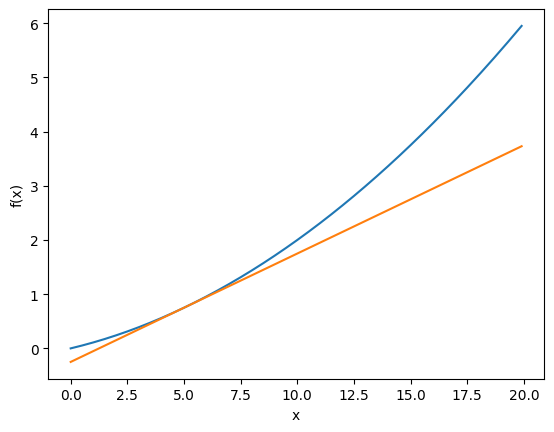

In [ ]:
### <gradient_1d> ### 중심 차분으로 수치 미분 구현
# coding: utf-8
import numpy as np
import matplotlib.pylab as plt


def numerical_diff(f, x):
    h = 1e-4 # 0.0001
    return (f(x+h) - f(x-h)) / (2*h)
    # 중심 차분과 적당히 작은 수 1e-4를 이용하여 미분값을 구함.


def function_1(x):
    return 0.01*x**2 + 0.1*x
    # 간단한 2차함수 예시


def tangent_line(f, x):
    d = numerical_diff(f, x)
    print(d)
    y = f(x) - d*x
    return lambda t: d*t + y
    # 접선

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")

tf = tangent_line(function_1, 5)
y2 = tf(x)

plt.plot(x, y)
plt.plot(x, y2)
plt.show()

/tmp/ipykernel_2247/366760951.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


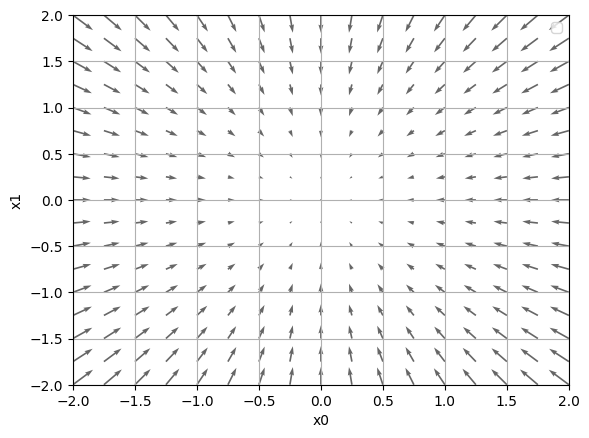

In [ ]:
### <gradient_2d> ###
# coding: utf-8
# cf.http://d.hatena.ne.jp/white_wheels/20100327/p3
import numpy as np
import matplotlib.pylab as plt
from mpl_toolkits.mplot3d import Axes3D


def _numerical_gradient_no_batch(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x) # x와 형상이 같은 배열을 생성

    for idx in range(x.size):
        tmp_val = x[idx]

        # f(x+h) 계산
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)       #중심 차분법으로 수치 미분
        x[idx] = tmp_val # 값 복원

    return grad
    # 기울기 구하기


def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)        # X와 똑같은 형태의 0으로 채워진 벡터

        for idx, x in enumerate(X):    # X에 담긴 값을 하나씩 꺼냄, X의 값과 인덱스 모두 반환
            grad[idx] = _numerical_gradient_no_batch(f, x)   # 각 X의 위치에 X의 기울기 채움

        return grad


def function_2(x):
    if x.ndim == 1:
        return np.sum(x**2)
    else:
        return np.sum(x**2, axis=1)


def tangent_line(f, x):
    d = numerical_gradient(f, x)
    print(d)
    y = f(x) - d*x
    return lambda t: d*t + y

if __name__ == '__main__':
    x0 = np.arange(-2, 2.5, 0.25)
    x1 = np.arange(-2, 2.5, 0.25)
    X, Y = np.meshgrid(x0, x1)            # 그리드 그리기

    X = X.flatten()
    Y = Y.flatten()

    grad = numerical_gradient(function_2, np.array([X, Y]) )          #

    plt.figure()
    plt.quiver(X, Y, -grad[0], -grad[1],  angles="xy",color="#666666")#,headwidth=10,scale=40,color="#444444")
    #기울기에 -를 취해서 값이 작아지는 곳으로 이동
    plt.xlim([-2, 2])
    plt.ylim([-2, 2])
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.grid()
    plt.legend()
    plt.draw()
    plt.show()

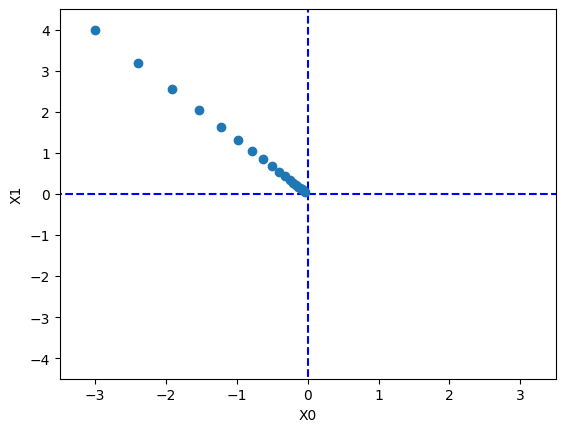

In [ ]:
### <gradient_method> ###
# coding: utf-8
import numpy as np
import matplotlib.pylab as plt


def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    x_history = []

    for i in range(step_num):
        x_history.append( x.copy() )

        grad = numerical_gradient(f, x)  # x의 기울기 구하기
        x -= lr * grad                   # x 갱신

    return x, np.array(x_history)
    # 경사하강법


def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])
# 초기값 설정

lr = 0.1 # 학습률
step_num = 20  # 반복 횟수
x, x_history = gradient_descent(function_2, init_x, lr=lr, step_num=step_num)
#

plt.plot( [-5, 5], [0,0], '--b')
plt.plot( [0,0], [-5, 5], '--b')
plt.plot(x_history[:,0], x_history[:,1], 'o')

plt.xlim(-3.5, 3.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("X0")
plt.ylabel("X1")
plt.show()

Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!
train acc, test acc | 0.09863333333333334, 0.0958
train acc, test acc | 0.8025333333333333, 0.8037
train acc, test acc | 0.8756333333333334, 0.8772
train acc, test acc | 0.89855, 0.8996
train acc, test acc | 0.9075166666666666, 0.9111
train acc, test acc | 0.91525, 0.9182
train acc, test acc | 0.9195666666666666, 0.9218
train acc, test acc | 0.9242333333333334, 0.9263
train acc, test acc | 0.9279666666666667, 0.9286
train acc, test acc | 0.9311666666666667, 0.9314
train acc, test acc | 0.9335833333333333, 0.9354
train acc, test acc | 0.93685, 0.9372
train acc, test acc | 0.9388333333333333, 0.9376
train acc, test acc | 0.9407833333333333, 0.9399
train acc, test acc | 0.942, 0.9406
train acc, test acc | 0.944133333

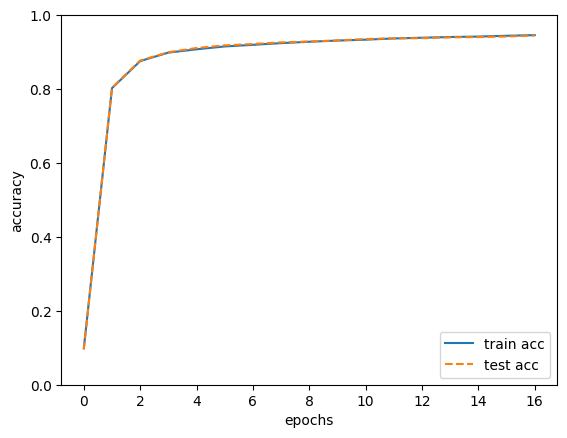

In [ ]:
### <train_neuralnet> ###
# coding: utf-8
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.functions import *
from common.gradient import numerical_gradient

## 2층 인공신경망 클래스
class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)
        # 가중치는 초기값, 편향은 0으로 초기화

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y
        # 2층 인공신경망 연산 (순전파)

    # x : 입력 데이터, t : 정답 레이블
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)
        # 오차 계산

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)         # 행 별로 가장 큰 값의 인덱스 (즉 예측 정답) 도출
        t = np.argmax(t, axis=1)         # 원-핫 인코딩된 정답에서 각 행 별로 가장 큰 인덱스 (즉 정답) 도출

        accuracy = np.sum(y == t) / float(x.shape[0])    # 정답을 맞춘 경우의 수(y == t가 True인 경우)를 모두 더하여 전체 크기로 나누어 정확도 계산
        return accuracy
        # 정확도 계산

    # x : 입력 데이터, t : 정답 레이블
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads
        # 각 파라미터(가중치, 편향)의 기울기 구하기

    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]

        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        # backward
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)

        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)

        return grads
        # 5장에서 설명

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

# 하이퍼파라미터
iters_num = 10000  # 반복 횟수를 적절히 설정한다.
train_size = x_train.shape[0]
batch_size = 100   # 미니배치 크기
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)
# 전체 데이터셋 / 배치 사이즈 = 배치 사이즈만큼 몇 번의 학습을 해야 전체를 다 학습하는지 반복하는 횟수 -> 한 번 배치 크기만큼 학습을 끝낼 때마다 정확도 출력
# (e.g. 60000장의 mnist 데이터셋을 100개 씩(배치 크기) 학습하면 600번 하면 완료)
# 미니배치 한 세트를 다 학습하면 정확도 계산 (max() 부분은 안전장치로 최소 1번 학습을 보장함)

for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산 : gradient를 이용하여 각 기울기 갱신(비슷한 능력을 더 빠르게 계산! 오차역전파 다음장에 나옴)
    #grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [ ]:
!git clone https://github.com/WegraLee/deep-learning-from-scratch.git

Cloning into 'deep-learning-from-scratch'...
remote: Enumerating objects: 1118, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 1118 (delta 141), reused 130 (delta 130), pack-reused 943 (from 2)
Receiving objects: 100% (1118/1118), 52.68 MiB | 26.76 MiB/s, done.
Resolving deltas: 100% (644/644), done.


In [ ]:
%cd deep-learning-from-scratch

/content/deep-learning-from-scratch
